# Meta-Learner Dataset Analysis: 2025 Season

This notebook:
- loads the generated meta-learner dataset
- filters to `SEASON_YEAR == 2025`
- evaluates each of the six base-model predictions as over/under picks
- builds ensemble baselines to beat later with a classifier
- compares whether aggregation improves on the best individual model

All baselines are evaluated in betting-direction space using `LINE_ERROR`:
- `LINE_ERROR > 0` => over
- `LINE_ERROR < 0` => under
- pushes (`LINE_ERROR == 0`) are excluded from accuracy, matching the project scorer convention


In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from nba_ou.modeling.scorers import over_under_betting_accuracy_error_line

pd.options.display.float_format = '{:,.4f}'.format

CSV_PATH = Path('/home/adrian_alvarez/Projects/NBA_over_under_predictor/data/train_data/meta_learner_last_2_seasons_20260405.csv')
SEASON_FILTER = 2025
LINE_COL = 'TOTAL_LINE_bet365'
TARGET_ERROR_COL = 'LINE_ERROR'
DATE_COL = 'GAME_DATE'
GAME_ID_COL = 'GAME_ID'


In [32]:
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

df_season = (
    df.loc[df['SEASON_YEAR'] == SEASON_FILTER]
    .sort_values([DATE_COL, GAME_ID_COL], kind='mergesort')
    .reset_index(drop=True)
)

TOTAL_MODEL_COLS = [c for c in df_season.columns if c.startswith('PRED_TOTAL_POINTS_')]
ERROR_MODEL_COLS = [c for c in df_season.columns if c.startswith('PRED_LINE_ERROR_')]
ALL_MODEL_COLS = TOTAL_MODEL_COLS + ERROR_MODEL_COLS

print(f'CSV path: {CSV_PATH}')
print(f'Rows in full dataset: {len(df):,}')
print(f'Rows in SEASON_YEAR == {SEASON_FILTER}: {len(df_season):,}')
print(f'Date range: {df_season[DATE_COL].min().date()} -> {df_season[DATE_COL].max().date()}')
print(f'Pushes in season: {(df_season[TARGET_ERROR_COL] == 0).sum():,}')
print('Total-points models:', TOTAL_MODEL_COLS)
print('Line-error models:', ERROR_MODEL_COLS)

display(df_season[[GAME_ID_COL, DATE_COL, 'SEASON_YEAR', 'TOTAL_POINTS', TARGET_ERROR_COL, LINE_COL] + ALL_MODEL_COLS].head())


CSV path: /home/adrian_alvarez/Projects/NBA_over_under_predictor/data/train_data/meta_learner_last_2_seasons_20260405.csv
Rows in full dataset: 2,317
Rows in SEASON_YEAR == 2025: 1,085
Date range: 2025-10-27 -> 2026-04-05
Pushes in season: 11
Total-points models: ['PRED_TOTAL_POINTS_FULL_DATASET', 'PRED_TOTAL_POINTS_LAST_5_SEASONS', 'PRED_TOTAL_POINTS_LAST_3_SEASONS']
Line-error models: ['PRED_LINE_ERROR_FULL_DATASET', 'PRED_LINE_ERROR_LAST_5_SEASONS', 'PRED_LINE_ERROR_LAST_3_SEASONS']


,GAME_ID,GAME_DATE,SEASON_YEAR,TOTAL_POINTS,LINE_ERROR,TOTAL_LINE_bet365,PRED_TOTAL_POINTS_FULL_DATASET,PRED_TOTAL_POINTS_LAST_5_SEASONS,PRED_TOTAL_POINTS_LAST_3_SEASONS,PRED_LINE_ERROR_FULL_DATASET,PRED_LINE_ERROR_LAST_5_SEASONS,PRED_LINE_ERROR_LAST_3_SEASONS
0,22500119,2025-10-27,2025,195,-31.5000,226.5000,223.6222,224.4400,223.4739,-1.5509,-3.3205,-2.1989
1,22500132,2025-10-29,2025,239,1.0000,238.0000,235.0012,233.8056,235.3959,-1.5480,-5.3507,-4.0474
2,22500133,2025-10-29,2025,212,-18.0000,230.0000,226.8199,223.3301,225.5889,-3.3577,-3.0655,-3.9342
3,22500135,2025-10-29,2025,270,34.5000,235.5000,233.4628,233.7675,231.9124,-1.8250,-2.0166,-1.5809
4,22500139,2025-10-30,2025,230,1.0000,229.0000,227.2798,229.5438,230.7391,-0.5074,-3.5506,-0.0105


In [33]:
def total_points_to_error(pred_total: pd.Series, line: pd.Series) -> pd.Series:
    return pd.to_numeric(pred_total, errors='coerce') - pd.to_numeric(line, errors='coerce')


def sign_series(values: pd.Series | np.ndarray) -> pd.Series:
    arr = np.asarray(values, dtype=float)
    return pd.Series(np.sign(arr), index=getattr(values, 'index', None))


def summarize_predictions(y_true_error: pd.Series, y_pred_error: pd.Series, label: str) -> dict:
    y_true = pd.to_numeric(y_true_error, errors='coerce').to_numpy(dtype=float)
    y_pred = pd.to_numeric(y_pred_error, errors='coerce').to_numpy(dtype=float)

    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    true_side = np.sign(y_true)
    pred_side = np.sign(y_pred)
    eligible = valid & (true_side != 0) & (pred_side != 0)
    actual_non_push = valid & (true_side != 0)
    residual = y_pred - y_true

    accuracy = over_under_betting_accuracy_error_line(
        y_true_error=y_true[valid],
        y_pred_error=y_pred[valid],
    )

    return {
        'model': label,
        'accuracy_pct': 100.0 * accuracy,
        'eligible_games': int(eligible.sum()),
        'coverage_pct_non_push': 100.0 * eligible.sum() / actual_non_push.sum(),
        'pred_push_rate_pct': 100.0 * np.mean(pred_side[valid] == 0),
        'mean_abs_predicted_edge': float(np.nanmean(np.abs(y_pred[valid]))),
        'mean_predicted_edge': float(np.nanmean(y_pred[valid])),
        'mae_vs_true_error': float(np.nanmean(np.abs(residual[valid]))),
        'rmse_vs_true_error': float(np.sqrt(np.nanmean(np.square(residual[valid])))),
        'bias_vs_true_error': float(np.nanmean(residual[valid])),
    }


def vote_from_error_columns(frame: pd.DataFrame, cols: list[str]) -> pd.Series:
    signs = np.sign(frame[cols].to_numpy(dtype=float))
    return pd.Series(np.sign(signs.sum(axis=1)), index=frame.index)


def majority_vote_with_mean_error_tiebreak(frame: pd.DataFrame, cols: list[str]) -> pd.Series:
    signs = np.sign(frame[cols].to_numpy(dtype=float))
    majority = np.sign(signs.sum(axis=1))
    tie_mask = majority == 0
    if np.any(tie_mask):
        mean_error = frame[cols].mean(axis=1).to_numpy(dtype=float)
        majority[tie_mask] = np.sign(mean_error[tie_mask])
    return pd.Series(majority, index=frame.index)


def majority_vote_with_reference_model_tiebreak(
    frame: pd.DataFrame,
    cols: list[str],
    reference_col: str,
) -> pd.Series:
    signs = np.sign(frame[cols].to_numpy(dtype=float))
    majority = np.sign(signs.sum(axis=1))
    tie_mask = majority == 0
    if np.any(tie_mask):
        reference_side = np.sign(frame[reference_col].to_numpy(dtype=float))
        majority[tie_mask] = reference_side[tie_mask]
    return pd.Series(majority, index=frame.index)


def weighted_average_error(frame: pd.DataFrame, cols: list[str], weights: dict[str, float]) -> pd.Series:
    weight_vector = np.array([weights[c] for c in cols], dtype=float)
    weight_vector = weight_vector / weight_vector.sum()
    values = frame[cols].to_numpy(dtype=float)
    return pd.Series(values @ weight_vector, index=frame.index)


def expanding_accuracy_weighted_average(frame: pd.DataFrame, cols: list[str]) -> pd.Series:
    frame_sorted = frame.sort_values([DATE_COL, GAME_ID_COL], kind='mergesort').copy()
    out = pd.Series(index=frame_sorted.index, dtype=float)

    correct_so_far = {col: 0.0 for col in cols}
    eligible_so_far = {col: 0 for col in cols}

    for current_day, day_df in frame_sorted.groupby(DATE_COL, sort=True):
        weights = []
        for col in cols:
            if eligible_so_far[col] == 0:
                weights.append(1.0)
            else:
                weights.append(correct_so_far[col] / eligible_so_far[col])

        weights = np.asarray(weights, dtype=float)
        if np.allclose(weights.sum(), 0.0):
            weights = np.ones_like(weights)
        weights = weights / weights.sum()

        out.loc[day_df.index] = day_df[cols].to_numpy(dtype=float) @ weights

        y_true = np.sign(day_df[TARGET_ERROR_COL].to_numpy(dtype=float))
        for col in cols:
            y_pred = np.sign(day_df[col].to_numpy(dtype=float))
            eligible = (y_true != 0) & (y_pred != 0)
            eligible_so_far[col] += int(eligible.sum())
            correct_so_far[col] += float(np.sum(y_true[eligible] == y_pred[eligible]))

    return out.reindex(frame.index)


In [34]:
df_eval = df_season.copy()

error_space_cols = []
for col in TOTAL_MODEL_COLS:
    err_col = f'{col}__ERR'
    df_eval[err_col] = total_points_to_error(df_eval[col], df_eval[LINE_COL])
    error_space_cols.append(err_col)

for col in ERROR_MODEL_COLS:
    err_col = f'{col}__ERR'
    df_eval[err_col] = pd.to_numeric(df_eval[col], errors='coerce')
    error_space_cols.append(err_col)

total_error_cols = [f'{col}__ERR' for col in TOTAL_MODEL_COLS]
line_error_cols = [f'{col}__ERR' for col in ERROR_MODEL_COLS]

individual_rows = []
for raw_col in TOTAL_MODEL_COLS + ERROR_MODEL_COLS:
    err_col = f'{raw_col}__ERR'
    family = 'total_points' if raw_col in TOTAL_MODEL_COLS else 'line_error'
    row = summarize_predictions(df_eval[TARGET_ERROR_COL], df_eval[err_col], raw_col)
    row['family'] = family
    individual_rows.append(row)

individual_summary = pd.DataFrame(individual_rows).sort_values('accuracy_pct', ascending=False).reset_index(drop=True)
display(individual_summary)


,model,accuracy_pct,eligible_games,coverage_pct_non_push,pred_push_rate_pct,mean_abs_predicted_edge,mean_predicted_edge,mae_vs_true_error,rmse_vs_true_error,bias_vs_true_error,family
0,PRED_LINE_ERROR_LAST_5_SEASONS,54.3762,1074,100.0000,0.0000,1.8005,-0.9484,13.5060,17.1537,-0.1079,line_error
1,PRED_TOTAL_POINTS_FULL_DATASET,53.2588,1074,100.0000,0.0000,2.6020,-1.1359,13.8096,17.4563,-0.2954,total_points
2,PRED_TOTAL_POINTS_LAST_5_SEASONS,53.0726,1074,100.0000,0.0000,2.4819,-0.8194,13.7389,17.3914,0.0212,total_points
3,PRED_LINE_ERROR_FULL_DATASET,52.8864,1074,100.0000,0.0000,2.2095,-1.2492,13.5520,17.1871,-0.4086,line_error
4,PRED_LINE_ERROR_LAST_3_SEASONS,52.1415,1074,100.0000,0.0000,2.1473,-1.2446,13.6017,17.2245,-0.4041,line_error
5,PRED_TOTAL_POINTS_LAST_3_SEASONS,52.0484,1074,100.0000,0.0000,2.1794,-0.8082,13.7777,17.4028,0.0323,total_points


In [35]:
side_cols = {}
for col in total_error_cols + line_error_cols:
    side_cols[col.replace('__ERR', '__SIDE')] = np.sign(df_eval[col].to_numpy(dtype=float))

side_df = pd.DataFrame(side_cols, index=df_eval.index)

def pairwise_agreement(a: pd.Series, b: pd.Series) -> float:
    valid = (a != 0) & (b != 0)
    if valid.sum() == 0:
        return np.nan
    return 100.0 * (a[valid] == b[valid]).mean()


agreement = pd.DataFrame(index=side_df.columns, columns=side_df.columns, dtype=float)
for col_a in side_df.columns:
    for col_b in side_df.columns:
        agreement.loc[col_a, col_b] = pairwise_agreement(side_df[col_a], side_df[col_b])

display(agreement.round(2))


,PRED_TOTAL_POINTS_FULL_DATASET__SIDE,PRED_TOTAL_POINTS_LAST_5_SEASONS__SIDE,PRED_TOTAL_POINTS_LAST_3_SEASONS__SIDE,PRED_LINE_ERROR_FULL_DATASET__SIDE,PRED_LINE_ERROR_LAST_5_SEASONS__SIDE,PRED_LINE_ERROR_LAST_3_SEASONS__SIDE
PRED_TOTAL_POINTS_FULL_DATASET__SIDE,100.0000,75.3900,69.3100,62.3000,64.9800,60.8300
PRED_TOTAL_POINTS_LAST_5_SEASONS__SIDE,75.3900,100.0000,73.2700,61.1100,68.9400,62.7600
PRED_TOTAL_POINTS_LAST_3_SEASONS__SIDE,69.3100,73.2700,100.0000,59.8200,65.6200,61.8400
PRED_LINE_ERROR_FULL_DATASET__SIDE,62.3000,61.1100,59.8200,100.0000,65.0700,71.2400
PRED_LINE_ERROR_LAST_5_SEASONS__SIDE,64.9800,68.9400,65.6200,65.0700,100.0000,66.5400
PRED_LINE_ERROR_LAST_3_SEASONS__SIDE,60.8300,62.7600,61.8400,71.2400,66.5400,100.0000


In [36]:
df_eval['BASE_AVG_ALL_6_ERR'] = df_eval[total_error_cols + line_error_cols].mean(axis=1)
df_eval['BASE_AVG_TOTAL_ONLY_ERR'] = df_eval[total_error_cols].mean(axis=1)
df_eval['BASE_AVG_LINE_ERROR_ONLY_ERR'] = df_eval[line_error_cols].mean(axis=1)
df_eval['BASE_AVG_GROUPS_EQUAL_WEIGHT_ERR'] = 0.5 * (
    df_eval['BASE_AVG_TOTAL_ONLY_ERR'] + df_eval['BASE_AVG_LINE_ERROR_ONLY_ERR']
)

df_eval['BASE_MAJORITY_ALL_6_ERR'] = vote_from_error_columns(df_eval, total_error_cols + line_error_cols)
df_eval['BASE_MAJORITY_TOTAL_ONLY_ERR'] = vote_from_error_columns(df_eval, total_error_cols)
df_eval['BASE_MAJORITY_LINE_ERROR_ONLY_ERR'] = vote_from_error_columns(df_eval, line_error_cols)
df_eval['BASE_GROUP_VOTE_TARGET_SPLIT_ERR'] = np.sign(
    np.sign(df_eval['BASE_AVG_TOTAL_ONLY_ERR']) + np.sign(df_eval['BASE_AVG_LINE_ERROR_ONLY_ERR'])
)

best_single_model_name = individual_summary.iloc[0]['model']
best_single_error_col = f'{best_single_model_name}__ERR'

all_six_vote_signs = np.sign(df_eval[total_error_cols + line_error_cols].to_numpy(dtype=float))
all_six_over_count = (all_six_vote_signs > 0).sum(axis=1)
all_six_under_count = (all_six_vote_signs < 0).sum(axis=1)
df_eval['IS_3_VS_3_SPLIT_ALL_6'] = (all_six_over_count == 3) & (all_six_under_count == 3)

df_eval['BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR'] = majority_vote_with_mean_error_tiebreak(
    df_eval,
    total_error_cols + line_error_cols,
)
df_eval['BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR'] = majority_vote_with_reference_model_tiebreak(
    df_eval,
    total_error_cols + line_error_cols,
    best_single_error_col,
)

season_acc_weights = individual_summary.set_index('model')['accuracy_pct'].div(100.0).to_dict()
df_eval['BASE_WEIGHTED_AVG_BY_2025_ACC_ERR'] = weighted_average_error(
    df_eval,
    total_error_cols + line_error_cols,
    {f'{col}__ERR': season_acc_weights[col] for col in TOTAL_MODEL_COLS + ERROR_MODEL_COLS},
)

df_eval['BASE_EXPANDING_WEIGHTED_AVG_BY_PAST_ACC_ERR'] = expanding_accuracy_weighted_average(
    df_eval,
    total_error_cols + line_error_cols,
)

baseline_cols = [
    'BASE_AVG_ALL_6_ERR',
    'BASE_AVG_TOTAL_ONLY_ERR',
    'BASE_AVG_LINE_ERROR_ONLY_ERR',
    'BASE_AVG_GROUPS_EQUAL_WEIGHT_ERR',
    'BASE_MAJORITY_ALL_6_ERR',
    'BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR',
    'BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR',
    'BASE_MAJORITY_TOTAL_ONLY_ERR',
    'BASE_MAJORITY_LINE_ERROR_ONLY_ERR',
    'BASE_GROUP_VOTE_TARGET_SPLIT_ERR',
    'BASE_WEIGHTED_AVG_BY_2025_ACC_ERR',
    'BASE_EXPANDING_WEIGHTED_AVG_BY_PAST_ACC_ERR',
]

baseline_summary = pd.DataFrame(
    [
        summarize_predictions(df_eval[TARGET_ERROR_COL], df_eval[col], col)
        for col in baseline_cols
    ]
).sort_values('accuracy_pct', ascending=False).reset_index(drop=True)

print(f"Best single model used as tie-break reference: {best_single_model_name}")
print(f"Exact 3-vs-3 splits across all 6 models: {int(df_eval['IS_3_VS_3_SPLIT_ALL_6'].sum()):,}")

display(baseline_summary)


Best single model used as tie-break reference: PRED_LINE_ERROR_LAST_5_SEASONS
Exact 3-vs-3 splits across all 6 models: 148


,model,accuracy_pct,eligible_games,coverage_pct_non_push,pred_push_rate_pct,mean_abs_predicted_edge,mean_predicted_edge,mae_vs_true_error,rmse_vs_true_error,bias_vs_true_error
0,BASE_MAJORITY_ALL_6_ERR,55.2207,929,86.4991,13.6406,0.8636,-0.4323,13.4553,17.0652,0.4083
1,BASE_GROUP_VOTE_TARGET_SPLIT_ERR,55.0725,759,70.6704,29.5853,0.7041,-0.4406,13.4691,17.0808,0.4000
2,BASE_WEIGHTED_AVG_BY_2025_ACC_ERR,54.9348,1074,100.0000,0.0000,1.6955,-1.0340,13.5228,17.1581,-0.1934
3,BASE_AVG_ALL_6_ERR,54.8417,1074,100.0000,0.0000,1.6964,-1.0343,13.5237,17.1586,-0.1937
4,BASE_AVG_GROUPS_EQUAL_WEIGHT_ERR,54.8417,1074,100.0000,0.0000,1.6964,-1.0343,13.5237,17.1586,-0.1937
5,BASE_EXPANDING_WEIGHTED_AVG_BY_PAST_ACC_ERR,54.7486,1074,100.0000,0.0000,1.7045,-1.0328,13.5278,17.1624,-0.1922
6,BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR,54.5624,1074,100.0000,0.0000,1.0000,-0.4562,13.4599,17.0740,0.3843
7,BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR,54.3762,1074,100.0000,0.0000,1.0000,-0.4544,13.4636,17.0738,0.3862
8,BASE_MAJORITY_TOTAL_ONLY_ERR,54.2831,1074,100.0000,0.0000,1.0000,-0.3327,13.4673,17.1006,0.5078
9,BASE_AVG_LINE_ERROR_ONLY_ERR,53.6313,1074,100.0000,0.0000,1.7067,-1.1474,13.5029,17.1246,-0.3069


In [37]:
tie_df = df_eval.loc[df_eval['IS_3_VS_3_SPLIT_ALL_6']].copy()

print(f"3-vs-3 split games: {len(tie_df):,}")

if len(tie_df) > 0:
    tie_analysis_cols = [
        'BASE_MAJORITY_ALL_6_ERR',
        'BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR',
        'BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR',
        best_single_error_col,
        'BASE_AVG_ALL_6_ERR',
    ]

    tie_summary = pd.DataFrame(
        [
            summarize_predictions(tie_df[TARGET_ERROR_COL], tie_df[col], col)
            for col in tie_analysis_cols
        ]
    ).sort_values('accuracy_pct', ascending=False).reset_index(drop=True)

    tie_preview_cols = [
        GAME_ID_COL,
        DATE_COL,
        TARGET_ERROR_COL,
        'BASE_MAJORITY_ALL_6_ERR',
        'BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR',
        'BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR',
        'BASE_AVG_ALL_6_ERR',
        best_single_error_col,
    ]

    display(tie_summary)
    display(tie_df[tie_preview_cols].head(15))
else:
    print('No exact 3-vs-3 games were found in this season.')


3-vs-3 split games: 148


,model,accuracy_pct,eligible_games,coverage_pct_non_push,pred_push_rate_pct,mean_abs_predicted_edge,mean_predicted_edge,mae_vs_true_error,rmse_vs_true_error,bias_vs_true_error
0,BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR,50.3448,145,100.0000,0.0000,1.0000,-0.1757,13.0338,16.3516,0.2095
1,BASE_AVG_ALL_6_ERR,50.3448,145,100.0000,0.0000,0.8761,0.1992,13.1366,16.3440,0.5843
2,BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR,48.9655,145,100.0000,0.0000,1.0000,-0.1622,13.0608,16.3495,0.2230
3,PRED_LINE_ERROR_LAST_5_SEASONS__ERR,48.9655,145,100.0000,0.0000,1.5156,-0.5609,13.1923,16.4565,-0.1757
4,BASE_MAJORITY_ALL_6_ERR,0.0000,0,0.0000,100.0000,0.0000,0.0000,13.0000,16.2837,0.3851


,GAME_ID,GAME_DATE,LINE_ERROR,BASE_MAJORITY_ALL_6_ERR,BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR,BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR,BASE_AVG_ALL_6_ERR,PRED_LINE_ERROR_LAST_5_SEASONS__ERR
14,22500144,2025-11-01,-7.0000,0.0000,1.0000,-1.0000,0.1152,-1.3814
17,22500148,2025-11-02,14.5000,0.0000,1.0000,-1.0000,0.2024,-2.5009
18,22500149,2025-11-02,1.0000,0.0000,1.0000,-1.0000,0.0370,-3.0045
20,22500151,2025-11-02,-4.0000,0.0000,1.0000,-1.0000,0.2239,-3.4166
23,22500155,2025-11-02,18.0000,0.0000,-1.0000,-1.0000,-0.5078,-3.1875
28,22500161,2025-11-03,-16.0000,0.0000,-1.0000,-1.0000,-0.5391,-0.9659
33,22500166,2025-11-04,9.5000,0.0000,-1.0000,-1.0000,-1.3312,-0.5065
53,22500031,2025-11-07,5.0000,0.0000,1.0000,-1.0000,0.1167,-0.1815
55,22500033,2025-11-07,-1.0000,0.0000,1.0000,-1.0000,0.5873,-0.3415
57,22500035,2025-11-07,-4.0000,0.0000,-1.0000,-1.0000,-0.8172,-0.0597


In [38]:
tie_strategy_results = []

# Full-season majority vote with tie-only fallback strategies.
tie_strategy_specs = [('MEAN_ALL_6', 'BASE_AVG_ALL_6_ERR')]
tie_strategy_specs += [(model_name, f'{model_name}__ERR') for model_name in TOTAL_MODEL_COLS + ERROR_MODEL_COLS]

for strategy_name, fallback_col in tie_strategy_specs:
    resolved_col = f'BASE_MAJORITY_ALL_6_TIE_WITH_{strategy_name}_ERR'
    df_eval[resolved_col] = df_eval['BASE_MAJORITY_ALL_6_ERR']
    fallback_side = np.sign(df_eval[fallback_col].to_numpy(dtype=float))
    df_eval.loc[df_eval['IS_3_VS_3_SPLIT_ALL_6'], resolved_col] = fallback_side[
        df_eval['IS_3_VS_3_SPLIT_ALL_6'].to_numpy()
    ]

    full_row = summarize_predictions(df_eval[TARGET_ERROR_COL], df_eval[resolved_col], resolved_col)
    full_row['scope'] = 'full_2025_season'
    full_row['fallback_source'] = strategy_name
    tie_strategy_results.append(full_row)

    if len(tie_df) > 0:
        tie_row = summarize_predictions(
            tie_df[TARGET_ERROR_COL],
            df_eval.loc[tie_df.index, resolved_col],
            resolved_col,
        )
        tie_row['scope'] = '3_vs_3_only'
        tie_row['fallback_source'] = strategy_name
        tie_strategy_results.append(tie_row)


tie_strategy_summary = (
    pd.DataFrame(tie_strategy_results)
    .sort_values(['scope', 'accuracy_pct'], ascending=[True, False])
    .reset_index(drop=True)
)

print('Tie fallback strategies: use majority vote everywhere, and only replace exact 3-vs-3 ties with the fallback model/mean.')
display(tie_strategy_summary)

if len(tie_df) > 0:
    display(
        tie_strategy_summary.loc[tie_strategy_summary['scope'] == '3_vs_3_only']
        .sort_values('accuracy_pct', ascending=False)
        .reset_index(drop=True)
    )


Tie fallback strategies: use majority vote everywhere, and only replace exact 3-vs-3 ties with the fallback model/mean.


,model,accuracy_pct,eligible_games,coverage_pct_non_push,pred_push_rate_pct,mean_abs_predicted_edge,mean_predicted_edge,mae_vs_true_error,rmse_vs_true_error,bias_vs_true_error,scope,fallback_source
0,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_F...,52.4138,145,100.0000,0.0000,1.0000,-0.3514,12.9865,16.2342,0.0338,3_vs_3_only,PRED_LINE_ERROR_FULL_DATASET
1,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_TOTAL_POINTS...,51.7241,145,100.0000,0.0000,1.0000,0.2703,13.0068,16.3053,0.6554,3_vs_3_only,PRED_TOTAL_POINTS_LAST_5_SEASONS
2,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_L...,51.0345,145,100.0000,0.0000,1.0000,-0.2973,13.0203,16.3264,0.0878,3_vs_3_only,PRED_LINE_ERROR_LAST_3_SEASONS
3,BASE_MAJORITY_ALL_6_TIE_WITH_MEAN_ALL_6_ERR,50.3448,145,100.0000,0.0000,1.0000,-0.1757,13.0338,16.3516,0.2095,3_vs_3_only,MEAN_ALL_6
4,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_TOTAL_POINTS...,48.9655,145,100.0000,0.0000,1.0000,0.4189,13.0541,16.2849,0.8041,3_vs_3_only,PRED_TOTAL_POINTS_LAST_3_SEASONS
5,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_L...,48.9655,145,100.0000,0.0000,1.0000,-0.1622,13.0608,16.3495,0.2230,3_vs_3_only,PRED_LINE_ERROR_LAST_5_SEASONS
6,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_TOTAL_POINTS...,46.8966,145,100.0000,0.0000,1.0000,0.1216,13.0946,16.3855,0.5068,3_vs_3_only,PRED_TOTAL_POINTS_FULL_DATASET
7,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_F...,54.8417,1074,100.0000,0.0000,1.0000,-0.4802,13.4535,17.0587,0.3604,full_2025_season,PRED_LINE_ERROR_FULL_DATASET
8,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_TOTAL_POINTS...,54.7486,1074,100.0000,0.0000,1.0000,-0.3954,13.4562,17.0680,0.4452,full_2025_season,PRED_TOTAL_POINTS_LAST_5_SEASONS
9,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_L...,54.6555,1074,100.0000,0.0000,1.0000,-0.4728,13.4581,17.0707,0.3677,full_2025_season,PRED_LINE_ERROR_LAST_3_SEASONS


,model,accuracy_pct,eligible_games,coverage_pct_non_push,pred_push_rate_pct,mean_abs_predicted_edge,mean_predicted_edge,mae_vs_true_error,rmse_vs_true_error,bias_vs_true_error,scope,fallback_source
0,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_F...,52.4138,145,100.0000,0.0000,1.0000,-0.3514,12.9865,16.2342,0.0338,3_vs_3_only,PRED_LINE_ERROR_FULL_DATASET
1,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_TOTAL_POINTS...,51.7241,145,100.0000,0.0000,1.0000,0.2703,13.0068,16.3053,0.6554,3_vs_3_only,PRED_TOTAL_POINTS_LAST_5_SEASONS
2,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_L...,51.0345,145,100.0000,0.0000,1.0000,-0.2973,13.0203,16.3264,0.0878,3_vs_3_only,PRED_LINE_ERROR_LAST_3_SEASONS
3,BASE_MAJORITY_ALL_6_TIE_WITH_MEAN_ALL_6_ERR,50.3448,145,100.0000,0.0000,1.0000,-0.1757,13.0338,16.3516,0.2095,3_vs_3_only,MEAN_ALL_6
4,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_TOTAL_POINTS...,48.9655,145,100.0000,0.0000,1.0000,0.4189,13.0541,16.2849,0.8041,3_vs_3_only,PRED_TOTAL_POINTS_LAST_3_SEASONS
5,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_L...,48.9655,145,100.0000,0.0000,1.0000,-0.1622,13.0608,16.3495,0.2230,3_vs_3_only,PRED_LINE_ERROR_LAST_5_SEASONS
6,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_TOTAL_POINTS...,46.8966,145,100.0000,0.0000,1.0000,0.1216,13.0946,16.3855,0.5068,3_vs_3_only,PRED_TOTAL_POINTS_FULL_DATASET


In [39]:
best_single_acc = individual_summary['accuracy_pct'].max()

summary_cols = [
    'model',
    'kind',
    'family',
    'accuracy_pct',
    'eligible_games',
    'coverage_pct_non_push',
    'pred_push_rate_pct',
    'mean_abs_predicted_edge',
    'mae_vs_true_error',
    'rmse_vs_true_error',
    'bias_vs_true_error',
]

combined_summary = pd.concat(
    [
        individual_summary.assign(kind='individual')[summary_cols],
        baseline_summary.assign(kind='baseline', family='ensemble')[summary_cols],
    ],
    ignore_index=True,
)

combined_summary['delta_vs_best_single_pp'] = combined_summary['accuracy_pct'] - best_single_acc
combined_summary = combined_summary.sort_values('accuracy_pct', ascending=False).reset_index(drop=True)

display(combined_summary)

print(f'Best single-model accuracy: {best_single_acc:.2f}%')
print('Top entries:')
display(combined_summary.head(15))


,model,kind,family,accuracy_pct,eligible_games,coverage_pct_non_push,pred_push_rate_pct,mean_abs_predicted_edge,mae_vs_true_error,rmse_vs_true_error,bias_vs_true_error,delta_vs_best_single_pp
0,BASE_MAJORITY_ALL_6_ERR,baseline,ensemble,55.2207,929,86.4991,13.6406,0.8636,13.4553,17.0652,0.4083,0.8445
1,BASE_GROUP_VOTE_TARGET_SPLIT_ERR,baseline,ensemble,55.0725,759,70.6704,29.5853,0.7041,13.4691,17.0808,0.4000,0.6963
2,BASE_WEIGHTED_AVG_BY_2025_ACC_ERR,baseline,ensemble,54.9348,1074,100.0000,0.0000,1.6955,13.5228,17.1581,-0.1934,0.5587
3,BASE_AVG_ALL_6_ERR,baseline,ensemble,54.8417,1074,100.0000,0.0000,1.6964,13.5237,17.1586,-0.1937,0.4655
4,BASE_AVG_GROUPS_EQUAL_WEIGHT_ERR,baseline,ensemble,54.8417,1074,100.0000,0.0000,1.6964,13.5237,17.1586,-0.1937,0.4655
5,BASE_EXPANDING_WEIGHTED_AVG_BY_PAST_ACC_ERR,baseline,ensemble,54.7486,1074,100.0000,0.0000,1.7045,13.5278,17.1624,-0.1922,0.3724
6,BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR,baseline,ensemble,54.5624,1074,100.0000,0.0000,1.0000,13.4599,17.0740,0.3843,0.1862
7,PRED_LINE_ERROR_LAST_5_SEASONS,individual,line_error,54.3762,1074,100.0000,0.0000,1.8005,13.5060,17.1537,-0.1079,0.0000
8,BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR,baseline,ensemble,54.3762,1074,100.0000,0.0000,1.0000,13.4636,17.0738,0.3862,0.0000
9,BASE_MAJORITY_TOTAL_ONLY_ERR,baseline,ensemble,54.2831,1074,100.0000,0.0000,1.0000,13.4673,17.1006,0.5078,-0.0931


Best single-model accuracy: 54.38%
Top entries:


,model,kind,family,accuracy_pct,eligible_games,coverage_pct_non_push,pred_push_rate_pct,mean_abs_predicted_edge,mae_vs_true_error,rmse_vs_true_error,bias_vs_true_error,delta_vs_best_single_pp
0,BASE_MAJORITY_ALL_6_ERR,baseline,ensemble,55.2207,929,86.4991,13.6406,0.8636,13.4553,17.0652,0.4083,0.8445
1,BASE_GROUP_VOTE_TARGET_SPLIT_ERR,baseline,ensemble,55.0725,759,70.6704,29.5853,0.7041,13.4691,17.0808,0.4000,0.6963
2,BASE_WEIGHTED_AVG_BY_2025_ACC_ERR,baseline,ensemble,54.9348,1074,100.0000,0.0000,1.6955,13.5228,17.1581,-0.1934,0.5587
3,BASE_AVG_ALL_6_ERR,baseline,ensemble,54.8417,1074,100.0000,0.0000,1.6964,13.5237,17.1586,-0.1937,0.4655
4,BASE_AVG_GROUPS_EQUAL_WEIGHT_ERR,baseline,ensemble,54.8417,1074,100.0000,0.0000,1.6964,13.5237,17.1586,-0.1937,0.4655
5,BASE_EXPANDING_WEIGHTED_AVG_BY_PAST_ACC_ERR,baseline,ensemble,54.7486,1074,100.0000,0.0000,1.7045,13.5278,17.1624,-0.1922,0.3724
6,BASE_MAJORITY_ALL_6_TIE_MEAN_ERR_ERR,baseline,ensemble,54.5624,1074,100.0000,0.0000,1.0000,13.4599,17.0740,0.3843,0.1862
7,PRED_LINE_ERROR_LAST_5_SEASONS,individual,line_error,54.3762,1074,100.0000,0.0000,1.8005,13.5060,17.1537,-0.1079,0.0000
8,BASE_MAJORITY_ALL_6_TIE_BEST_MODEL_ERR,baseline,ensemble,54.3762,1074,100.0000,0.0000,1.0000,13.4636,17.0738,0.3862,0.0000
9,BASE_MAJORITY_TOTAL_ONLY_ERR,baseline,ensemble,54.2831,1074,100.0000,0.0000,1.0000,13.4673,17.1006,0.5078,-0.0931


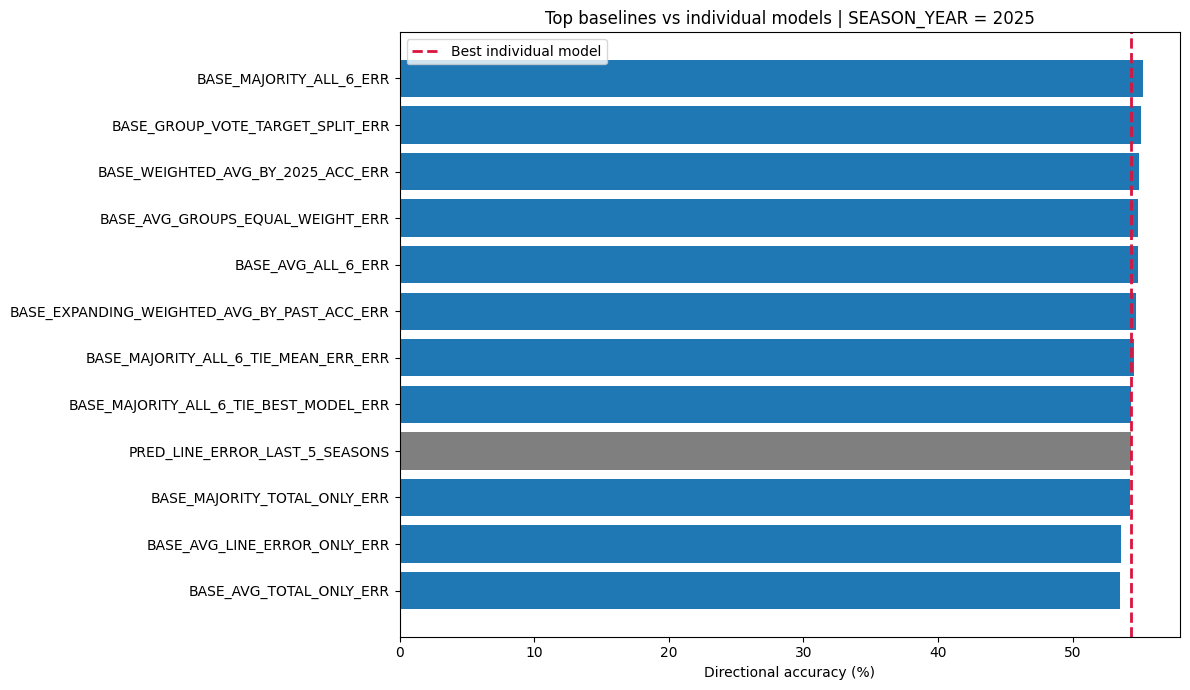

In [40]:
plot_df = combined_summary.head(12).sort_values('accuracy_pct', ascending=True)

plt.figure(figsize=(12, 7))
colors = np.where(plot_df['kind'].eq('baseline'), '#1f77b4', '#7f7f7f')
plt.barh(plot_df['model'], plot_df['accuracy_pct'], color=colors)
plt.axvline(best_single_acc, color='crimson', linestyle='--', linewidth=2, label='Best individual model')
plt.xlabel('Directional accuracy (%)')
plt.title(f'Top baselines vs individual models | SEASON_YEAR = {SEASON_FILTER}')
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
edge_thresholds = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
edge_rows = []

for raw_model_col in TOTAL_MODEL_COLS + ERROR_MODEL_COLS:
    err_col = f'{raw_model_col}__ERR'
    family = 'total_points' if raw_model_col in TOTAL_MODEL_COLS else 'line_error'

    y_true = pd.to_numeric(df_eval[TARGET_ERROR_COL], errors='coerce').to_numpy(dtype=float)
    y_pred = pd.to_numeric(df_eval[err_col], errors='coerce').to_numpy(dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    true_side = np.sign(y_true)
    pred_side = np.sign(y_pred)
    non_push = valid & (true_side != 0) & (pred_side != 0)

    base_accuracy = over_under_betting_accuracy_error_line(
        y_true_error=y_true[valid],
        y_pred_error=y_pred[valid],
    )

    for threshold in edge_thresholds:
        take = non_push & (np.abs(y_pred) > threshold)
        n_games = int(take.sum())
        accuracy = (
            np.nan
            if n_games == 0
            else 100.0 * np.mean(true_side[take] == pred_side[take])
        )

        edge_rows.append(
            {
                'model': raw_model_col,
                'family': family,
                'threshold_abs_pred_error_gt': threshold,
                'n_games': n_games,
                'pct_of_non_push_games': 100.0 * n_games / int(non_push.sum()),
                'accuracy_pct': accuracy,
                'lift_vs_no_threshold_pp': accuracy - 100.0 * base_accuracy if n_games > 0 else np.nan,
                'mean_abs_predicted_edge_taken': float(np.nanmean(np.abs(y_pred[take]))) if n_games > 0 else np.nan,
            }
        )

edge_threshold_summary = pd.DataFrame(edge_rows)

print('Directional accuracy by minimum absolute predicted edge.')
display(edge_threshold_summary)

edge_threshold_pivot = edge_threshold_summary.pivot_table(
    index='model',
    columns='threshold_abs_pred_error_gt',
    values='accuracy_pct',
)
display(edge_threshold_pivot.round(2))

edge_lift_pivot = edge_threshold_summary.pivot_table(
    index='model',
    columns='threshold_abs_pred_error_gt',
    values='lift_vs_no_threshold_pp',
)
display(edge_lift_pivot.round(2))

best_threshold_by_model = (
    edge_threshold_summary.sort_values(['model', 'accuracy_pct', 'n_games'], ascending=[True, False, False])
    .groupby('model', as_index=False)
    .first()
    .sort_values('accuracy_pct', ascending=False)
    .reset_index(drop=True)
)
display(best_threshold_by_model)


Directional accuracy by minimum absolute predicted edge.


,model,family,threshold_abs_pred_error_gt,n_games,pct_of_non_push_games,accuracy_pct,lift_vs_no_threshold_pp,mean_abs_predicted_edge_taken
0,PRED_TOTAL_POINTS_FULL_DATASET,total_points,0.0000,1074,100.0000,53.2588,0.0000,2.6085
1,PRED_TOTAL_POINTS_FULL_DATASET,total_points,0.5000,905,84.2644,53.5912,0.3323,3.0513
2,PRED_TOTAL_POINTS_FULL_DATASET,total_points,1.0000,751,69.9255,54.5939,1.3350,3.5227
3,PRED_TOTAL_POINTS_FULL_DATASET,total_points,1.5000,621,57.8212,55.0725,1.8136,3.9975
4,PRED_TOTAL_POINTS_FULL_DATASET,total_points,2.0000,510,47.4860,54.7059,1.4470,4.4874
5,PRED_TOTAL_POINTS_FULL_DATASET,total_points,2.5000,407,37.8957,52.8256,-0.4333,5.0512
6,PRED_TOTAL_POINTS_FULL_DATASET,total_points,3.0000,323,30.0745,50.7740,-2.4849,5.6457
7,PRED_TOTAL_POINTS_LAST_5_SEASONS,total_points,0.0000,1074,100.0000,53.0726,0.0000,2.4879
8,PRED_TOTAL_POINTS_LAST_5_SEASONS,total_points,0.5000,909,84.6369,53.9054,0.8328,2.8901
9,PRED_TOTAL_POINTS_LAST_5_SEASONS,total_points,1.0000,761,70.8566,54.2707,1.1981,3.3079


threshold_abs_pred_error_gt,0.0000,0.5000,1.0000,1.5000,2.0000,2.5000,3.0000
model,,,,,,,
PRED_LINE_ERROR_FULL_DATASET,52.8900,52.4800,52.7700,53.7200,54.4200,53.8700,52.8700
PRED_LINE_ERROR_LAST_3_SEASONS,52.1400,51.9400,52.7700,52.2100,53.2000,54.1400,53.4100
PRED_LINE_ERROR_LAST_5_SEASONS,54.3800,53.6800,53.8600,53.5600,52.6200,53.0600,55.7300
PRED_TOTAL_POINTS_FULL_DATASET,53.2600,53.5900,54.5900,55.0700,54.7100,52.8300,50.7700
PRED_TOTAL_POINTS_LAST_3_SEASONS,52.0500,52.5200,52.4500,51.3800,49.8800,49.6700,50.4400
PRED_TOTAL_POINTS_LAST_5_SEASONS,53.0700,53.9100,54.2700,54.5500,54.7500,53.7000,55.0900


threshold_abs_pred_error_gt,0.0000,0.5000,1.0000,1.5000,2.0000,2.5000,3.0000
model,,,,,,,
PRED_LINE_ERROR_FULL_DATASET,0.0000,-0.4100,-0.1200,0.8400,1.5300,0.9800,-0.0200
PRED_LINE_ERROR_LAST_3_SEASONS,0.0000,-0.2000,0.6300,0.0700,1.0500,2.0000,1.2600
PRED_LINE_ERROR_LAST_5_SEASONS,0.0000,-0.7000,-0.5200,-0.8200,-1.7600,-1.3100,1.3500
PRED_TOTAL_POINTS_FULL_DATASET,0.0000,0.3300,1.3400,1.8100,1.4500,-0.4300,-2.4800
PRED_TOTAL_POINTS_LAST_3_SEASONS,0.0000,0.4700,0.4000,-0.6600,-2.1700,-2.3800,-1.6100
PRED_TOTAL_POINTS_LAST_5_SEASONS,0.0000,0.8300,1.2000,1.4700,1.6700,0.6300,2.0200


,model,family,threshold_abs_pred_error_gt,n_games,pct_of_non_push_games,accuracy_pct,lift_vs_no_threshold_pp,mean_abs_predicted_edge_taken
0,PRED_LINE_ERROR_LAST_5_SEASONS,line_error,3.0000,192,17.8771,55.7292,1.3530,3.9471
1,PRED_TOTAL_POINTS_LAST_5_SEASONS,total_points,3.0000,285,26.5363,55.0877,2.0151,5.6504
2,PRED_TOTAL_POINTS_FULL_DATASET,total_points,1.5000,621,57.8212,55.0725,1.8136,3.9975
3,PRED_LINE_ERROR_FULL_DATASET,line_error,2.0000,498,46.3687,54.4177,1.5313,3.6463
4,PRED_LINE_ERROR_LAST_3_SEASONS,line_error,2.5000,362,33.7058,54.1436,2.0021,4.0953
5,PRED_TOTAL_POINTS_LAST_3_SEASONS,total_points,0.5000,893,83.1471,52.5196,0.4712,2.5818


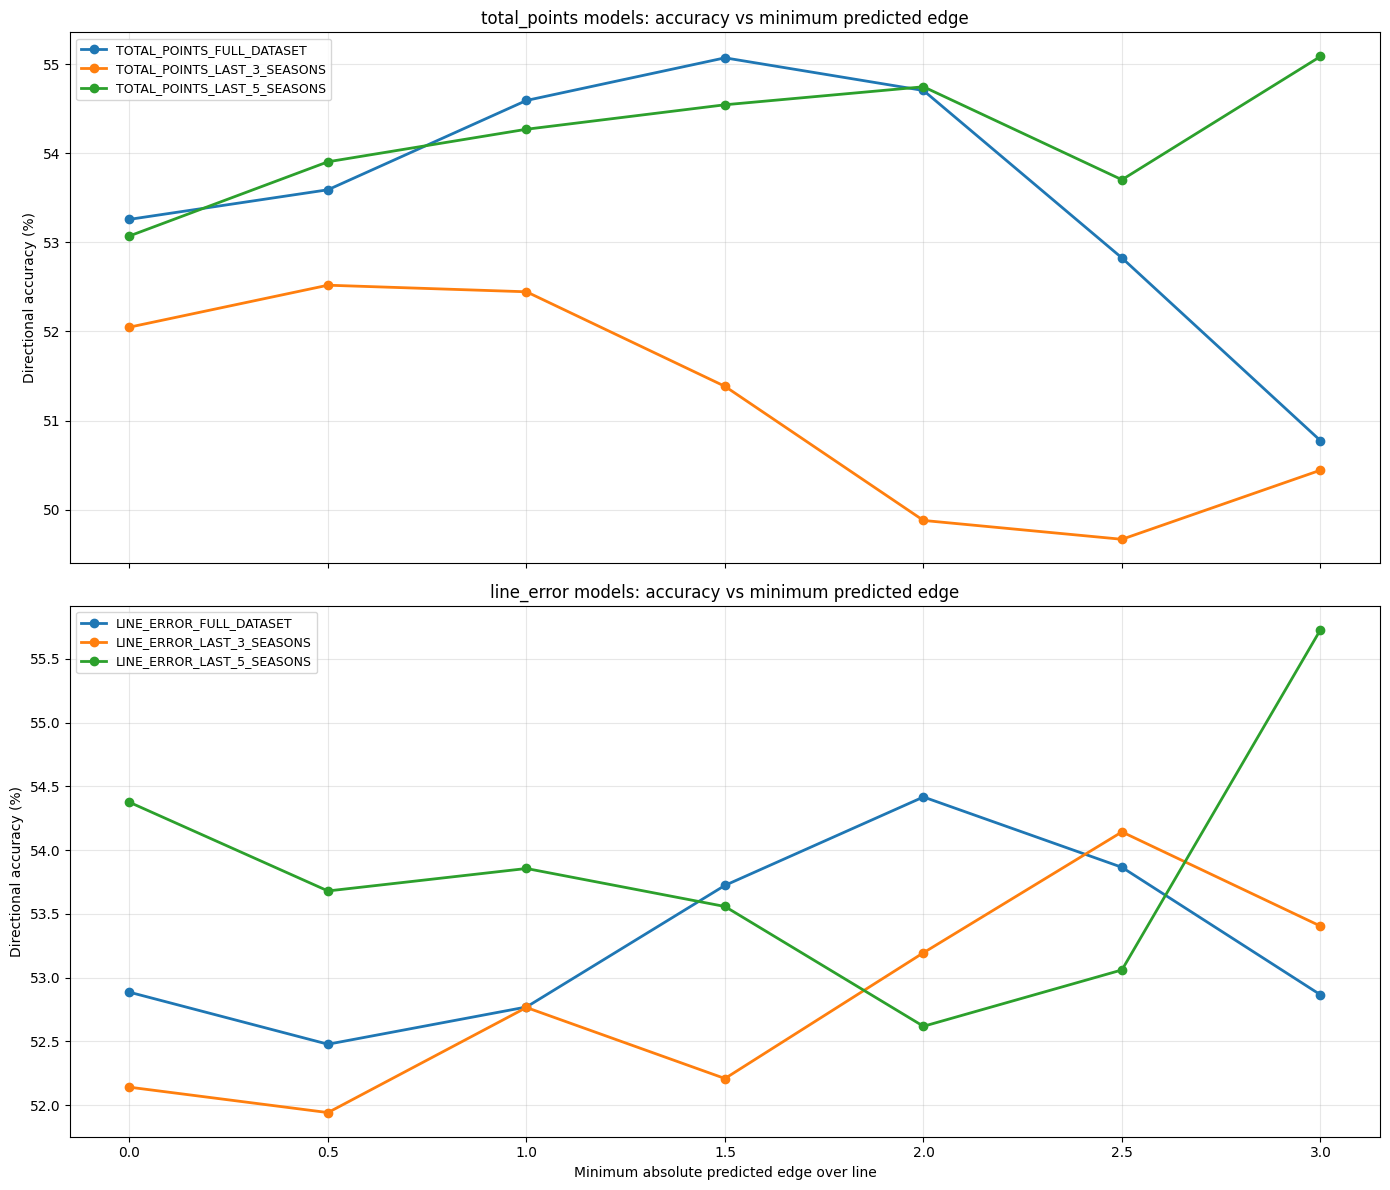

In [42]:
plot_df = edge_threshold_summary.copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
family_to_ax = {
    'total_points': axes[0],
    'line_error': axes[1],
}

for family, ax in family_to_ax.items():
    family_df = plot_df.loc[plot_df['family'] == family].copy()
    for model_name, model_df in family_df.groupby('model'):
        model_df = model_df.sort_values('threshold_abs_pred_error_gt')
        ax.plot(
            model_df['threshold_abs_pred_error_gt'],
            model_df['accuracy_pct'],
            marker='o',
            linewidth=2,
            label=model_name.replace('PRED_', ''),
        )

    ax.set_title(f'{family} models: accuracy vs minimum predicted edge')
    ax.set_ylabel('Directional accuracy (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

axes[1].set_xlabel('Minimum absolute predicted edge over line')
plt.tight_layout()
plt.show()


## Reading the Results

Recommended interpretation order:
1. Compare the best baseline against the best single model.
2. Check whether aggregation helps more when combining all 6 models or when splitting by target family.
3. Compare the leakage-safe `BASE_EXPANDING_WEIGHTED_AVG_BY_PAST_ACC_ERR` against the leaky upper-bound `BASE_WEIGHTED_AVG_BY_2025_ACC_ERR`.
4. Use the agreement matrix to judge whether the classifier still has ensemble headroom.

If the best simple aggregation already beats every single model, the classifier should beat that baseline, not just the individual models.
